<div style="background: linear-gradient(135deg, rgb(36, 233, 217) 0%, rgb(196, 16, 202) 30%, rgb(255, 255, 255) 60%);
            padding: 10px; border-radius: 8px; margin: 10px 0; color: black; font-family: Arial, sans-serif; text-align: center; font-size: 24px;">

# **Система поиска подходящих товаров на основе дообученной CLIP модели**
</div>

### Цель
1. Дообучить модель CLIP на датасете товаров из магазинов одежды,
2. Реализовать систему поиска изображений товаров по текстовым запросам.

**Целевые значения среднего CLIP score должны быть выше 30.**

### Данные:
Датасет содержит картинки и таблицу: 
- **image** — название файла изображения в папке с изображениями.
- **description** — описание элемента одежды, изображённого на картинке.
- **display name** — название элемента на картинке.
- **category** — категория элемента одежды.

### Задание

**Этап 1. Fine-tuning CLIP**

1.1 Работа с данными

- Загрузить датасет и визуализовать часть данных.
- Выполнить предобработку данных.
- Реализовать свой класс датасета, который будет подгружать картинки и соответствующие им текстовые описания.

1.2 Работа с моделью

- Загрузить предобученную модель CLIP из библиотеки transformers. 
- Прогнать через модель несколько примеров из датасета и посмотреть какие получаются CLIP-скоры.

1.3 Дообучение

- Реализовать цикл обучения модели CLIP со стандартной функцией потерь.
- Реализовать функцию валидации, которая будет замерять средний CLIP score на всей тестовой выборке в конце эпохи обучения.
- Дообучь модель.
- Сделайть checkpoint-ы модели.
- После обучения вывести кривые функции потерь и CLIP score на трейне и CLIP score на валидации. 

**Этап 2. Реализация системы поиска товаров**

2.1 Работа с данными
- Взять датасет целеком. Загрузить чекпоинт дообученной модели и сохраните все векторные представления изображений.

2.2 Функция поиска товаров
- Написать функцию поиска товаров.
Функция должна принимать такие аргументы: 
- - модель,
- - данные из всего датасета,
- - текстовый запрос пользователя,
- - количество наиболее релевантных товаров, которые будут показываться пользователю. 
- - Формат аргументов выберите самостоятельно. Если нужно, передавайте в функцию дополнительные аргументы. 
- - Функция должна вычислять векторное представление текстового запроса пользователя, находить заданное количество наиболее актуальных картинок с товарами и возвращать их.

2.3 Протестировать написанную функцию.


#### **Окружение:**

```terminal
ОС:                  Linux 6.6.87.2-microsoft-standard-WSL2
Окружение:           WSL (Windows Subsystem for Linux)

Процессор:           
Ядер (физ):          12
Ядер (лог):          24
Модель CPU:          13th Gen Intel(R) Core(TM) i7-13700K

ОЗУ всего:           16.6 GB
PyTorch версия:      2.11.0+cu130
CUDA доступна:       True
GPU:                 NVIDIA GeForce RTX 4070
CUDA версия:         13.0
VRAM всего:          12.9 GB
```

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(36, 233, 217) 0%, rgb(196, 16, 202) 30%, rgb(255, 255, 255) 60%, rgb(255, 255, 255) 100%); border-left: 4px solid #ffffff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: rgb(0, 0, 0); font-weight: 600;">БЛОК 0. Импорт библиотек</strong>
</div>

In [1]:
import os
import math
import random
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPModel, CLIPProcessor
from transformers import get_cosine_schedule_with_warmup

from tqdm.auto import tqdm

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(36, 233, 217) 0%, rgb(196, 16, 202) 30%, rgb(255, 255, 255) 60%, rgb(255, 255, 255) 100%); border-left: 4px solid #ffffff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: rgb(0, 0, 0); font-weight: 600;">БЛОК 1.1 Fine-tuning CLIP. Работа с данными </strong>
</div>

Зафиксируем seed, чтобы результаты воспроизводились одинаковы, зададим устройство, пути и гиперпараметры обучения. Кароче говоря наш пульт управления

In [ ]:
# Наша воспроизводимость
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Покажем что gpu cuda с нами
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Устройство: {DEVICE}")

# Занесем основные пути наших данных
PROJECT_DIR = "/mnt/d/code/ya_neiro/PROJECT_NLP_CV_LLM/Система поиска подходящих товаров на основе дообученной CLIP модели"
DATA_ROOT = os.path.join(PROJECT_DIR, "data") # Общая папка
CSV_PATH = os.path.join(DATA_ROOT, "data.csv") #табличка
IMAGE_DIR = os.path.join(DATA_ROOT, "data") #картинки



# ну и результаты обучения сохраним в отдельной папке
CKPT_DIR    = os.path.join(PROJECT_DIR, "checkpoints")
EMB_PATH    = os.path.join(PROJECT_DIR, "image_embeddings.pt")
# Ну и папочку
os.makedirs(CKPT_DIR, exist_ok=True)


# Гиперпараметры
MODEL_NAME = "openai/clip-vit-base-patch32"
BATCH_SIZE = 32 # на мою gpu должно помещаться
NUM_EPOCHS = 4 #  эпохи
LR = 1e-5 # lr
WEIGHT_DECAY = 0.1
MAX_TEXT_LEN = 77 # предел текстового энкодера CLIP - вшито вроде как в архитектуру
TEST_SIZE = 0.10 # 10% на тест
NUM_WORKERS = 4 # параллельная загрузка помогает

# На случай быстрой итерации ограничитель трейна для экспериментов
MAX_TRAIN_SAMPLES = None

#  чтобы ошибок не вылетало
DTYPE = torch.float32

Устройство: cuda


тут тоже наши эксперименты для ускорения всего процесса, возможность сжатия и закидывания в систему wsl, для быстрого обучения и индексации

In [3]:
DO_RESIZE_CACHE = False
RESIZED_DIR = os.path.expanduser("~/clip_fashion_224")

if DO_RESIZE_CACHE:
    from concurrent.futures import ThreadPoolExecutor
    os.makedirs(RESIZED_DIR, exist_ok=True)
    files = [f for f in os.listdir(IMAGE_DIR) if f.lower().endswith((".jpg", ".jpeg", ".png"))]

    def _resize(fn):
        dst = os.path.join(RESIZED_DIR, fn)
        if os.path.exists(dst):
            return
        try:
            im = Image.open(os.path.join(IMAGE_DIR, fn)).convert("RGB")
            im.thumbnail((224, 224), Image.BICUBIC)
            im.save(dst, quality=90)
        except Exception as e:
            print("skip", fn, e)

    with ThreadPoolExecutor(max_workers=8) as ex:
        list(ex.map(_resize, files))
    IMAGE_DIR = RESIZED_DIR
    print("Готово. IMAGE_DIR", IMAGE_DIR)
else:
    print("Предресайз пропущен, берем оригиналы:", IMAGE_DIR)

Предресайз пропущен, берем оригиналы: /mnt/d/code/ya_neiro/PROJECT_NLP_CV_LLM/Система поиска подходящих товаров на основе дообученной CLIP модели/data/data


Непосредственно переходим к загрузки данных и загружаем и анализируем таблицу, смотрим примеры, разрешение и длину описаний.

In [4]:
df_raw = pd.read_csv(CSV_PATH)
print("Размер таблицы:", df_raw.shape)
df_raw.head()

Размер таблицы: (44441, 4)


,image,description,display name,category
0,3238.jpg,"Round toed, black sports shoes with red accent...",Puma Men Black 65CC Lo Ducati Sports Shoes,Sports Shoes
1,43044.jpg,Style Note Built with the breathability and ze...,Nike Men Charcoal Grey Shorts,Shorts
2,54018.jpg,Teal handbag that has stitch detailing with a...,Kiara Women Teal Handbag,Handbags
3,8141.jpg,"Perfectly stylish, this fastrack analog wrist ...",Fastrack Women Freestyle Sports Analog Steel B...,Watches
4,22245.jpg,These id mid-top chukka shoes add a fresh spin...,ID Men Brown Casual Shoes,Casual Shoes


итого 44 441 у нас записей, 4 колонки, но для наших целей (согласно ТЗ) оставим первые две это  название файлов изображения и описания, а также чекни на пропуска. 

In [5]:
df = df_raw[["image", "description"]].copy()
print(df.isna().sum())
df.head()

image            0
description    281
dtype: int64


,image,description
0,3238.jpg,"Round toed, black sports shoes with red accent..."
1,43044.jpg,Style Note Built with the breathability and ze...
2,54018.jpg,Teal handbag that has stitch detailing with a...
3,8141.jpg,"Perfectly stylish, this fastrack analog wrist ..."
4,22245.jpg,These id mid-top chukka shoes add a fresh spin...


колонки отформатированы, и мы видим, что 281 штука описаний отсутствует, чуток позже её предобработаем. Для начала взглянем как у нас выглядят картинки и описания к ним визуально

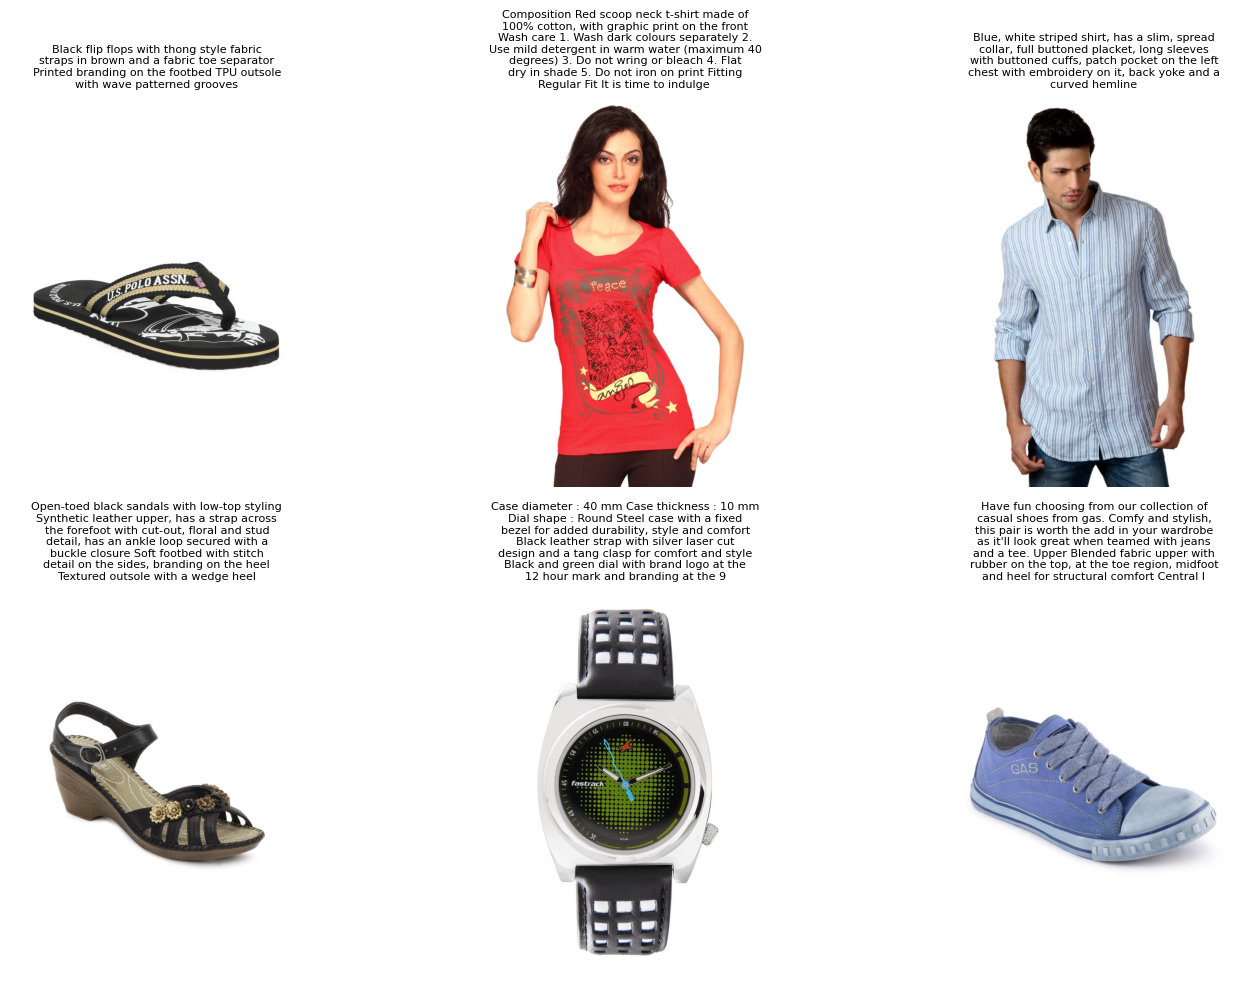

In [6]:
def show_samples(df, image_dir, n=6, seed=SEED):
    
    """Показывает картинку и её текстовое описание

    Args:
        df (_type_): датафрейм
        image_dir (_type_): картинка
        n (int, optional): Количество примеров. Defaults to 6.
        seed (_type_, optional): Ну и чтобы не болтались разные. Defaults to SEED.
    """    
    
    sample = df.dropna(subset=["description"]).sample(min(n, len(df)), random_state=seed)
    cols = 3
    rows = math.ceil(len(sample) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = np.array(axes).flatten()
    for ax in axes:
        ax.axis("off")
    for ax, (_, r) in zip(axes, sample.iterrows()):
        img = Image.open(os.path.join(image_dir, str(r["image"]))).convert("RGB")
        ax.imshow(img)
        ax.set_title(textwrap.fill(str(r["description"]), 45)[:300], fontsize=8)
    plt.tight_layout()
    plt.show()

show_samples(df, IMAGE_DIR, n=6)

Ну вроде походе на правду. Теперь взглянем какого размера у нас картинки перед подачей в модель

In [7]:
sizes = []
for f in df["image"].sample(min(300, len(df)), random_state=SEED):
    p = os.path.join(IMAGE_DIR, str(f))
    if os.path.exists(p):
        with Image.open(p) as im:
            sizes.append(im.size)  # (W, H)

size_counts = pd.Series([tuple(s) for s in sizes]).value_counts()
print("Топ разрешений (W, H):")
print(size_counts.head(10))

Топ разрешений (W, H):
(1080, 1440)    300
Name: count, dtype: int64


Моделька их должна ужать до 224х224, посмотрим на длину описание

count    44160.0
mean        93.8
std         56.9
min          0.0
25%         42.0
50%        102.0
75%        130.0
max       1117.0
Name: description, dtype: float64


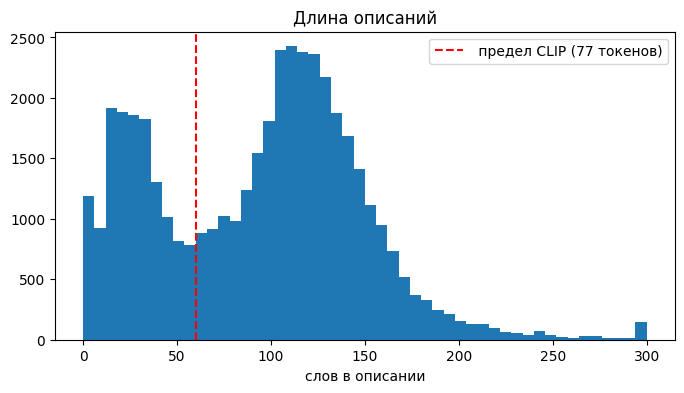

In [8]:
desc_len = df["description"].dropna().astype(str).str.split().apply(len)
print(desc_len.describe().round(1))


plt.figure(figsize=(8, 4))
plt.hist(desc_len.clip(upper=300), bins=50)
plt.axvline(60, ls="--", c="r", label=" предел CLIP (77 токенов)")
plt.title("Длина описаний")
plt.xlabel("слов в описании")
plt.legend()
plt.show()

Ну мы видим, что передел за предел CLIP у нас выходит очень большое количество описаний. Может какая проработка нужна? Может добавить нейронку, которая проанализирует это описания и сократит до необходимой нормы?
Это мысли на случай, если не будет достигнут score, а пока что в рамках учебного проекта выполним обрезку хвоста с надеждой на то, что самая главная суть описания заключена в наши 77 токенов.

Теперь непосредственна наша чистка данных от дублей и пустых строк обнаруженных

In [9]:
before = len(df)

df = df.dropna(subset=["image", "description"])
df = df[df["description"].astype(str).str.strip() != ""]
df = df.drop_duplicates(subset=["image", "description"])

existing = set(os.listdir(IMAGE_DIR))
df = df[df["image"].astype(str).isin(existing)].reset_index(drop=True)

print(f"Было: {before}, стало: {len(df)}")
df.head()

Было: 44441, стало: 44158


,image,description
0,3238.jpg,"Round toed, black sports shoes with red accent..."
1,43044.jpg,Style Note Built with the breathability and ze...
2,54018.jpg,Teal handbag that has stitch detailing with a...
3,8141.jpg,"Perfectly stylish, this fastrack analog wrist ..."
4,22245.jpg,These id mid-top chukka shoes add a fresh spin...


Ну с данными считаю пока что предобработки минимальной хватит, перейдем к разделению датасета. Предлагается как в нашем изначальном пульте задано 10% (как в ТЗ) тестовых данных отложить, остальное на дообучение

In [10]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=TEST_SIZE, random_state=SEED, shuffle=True)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# экспериментально ограничение трейна для быстрой первой итерации
if MAX_TRAIN_SAMPLES is not None and MAX_TRAIN_SAMPLES < len(train_df):
    train_df = train_df.sample(MAX_TRAIN_SAMPLES, random_state=SEED).reset_index(drop=True)

print("train:", len(train_df), "\n" "test:", len(test_df))

train: 39742 
test: 4416


Класс датасета сделаем, токенизацию и препроцессинг изображения батчем делаем в collate_fn через CLIPProcessor.

In [11]:
class FashionDataset(Dataset):
    """По номеру выдать одну пару картинка и текст описания. А потом лоадер соберет из пар батчи

    Args:
        Dataset (_type_): датасет
    """    
    def __init__(self, df, image_dir):
        """Инит

        Args:
            df (_type_): Датасет
            image_dir (_type_): папка картинок
        """        
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir

    def __len__(self):
        return len(self.df) #посчитали элементы

    def __getitem__(self, idx):
        """Вызывает когда нужен элемент

        Args:
            idx (_type_): элемент

        Returns:
            _type_: пара на возврат
        """        
        r = self.df.iloc[idx]
        img = Image.open(os.path.join(self.image_dir, str(r["image"]))).convert("RGB")
        text = str(r["description"])
        return img, text

Ну вроде как заканчиваем с первым пунктом, данные загрузили и визуализировали всё это дело, сделали минимум предобработку, и реализовали свой класс, можем идти дальше

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(36, 233, 217) 0%, rgb(196, 16, 202) 30%, rgb(255, 255, 255) 60%, rgb(255, 255, 255) 100%); border-left: 4px solid #ffffff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: rgb(0, 0, 0); font-weight: 600;">БЛОК 1.2 Работа с моделью </strong>
</div>

Загружаем предобученный CLIP, прогоняем примеры и смотрим CLIP-скоры до дообучения.

In [12]:
model = CLIPModel.from_pretrained(MODEL_NAME).to(DEVICE)
processor = CLIPProcessor.from_pretrained(MODEL_NAME)
print("Количество параметров:", round(sum(p.numel() for p in model.parameters()) / 1e6, 1), "M")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Количество параметров: 151.3 M


151 миллион параметров у нас, перейдем к сборке батчей.

In [13]:
def collate_fn(batch):
    """Превращаем список пар в один батч для модели с использованием CLIPProcessor для маштабируемости нормализации

    Args:
        batch (_type_): Ьаич

    Returns:
        _type_: словарь тензоров для модели
    """    
    images = [b[0] for b in batch]
    texts = [b[1] for b in batch]
    inputs = processor(
        text=texts, images=images, return_tensors="pt",
        padding=True, truncation=True, max_length=MAX_TEXT_LEN,
    )
    return inputs

train_loader = DataLoader(
    FashionDataset(train_df, IMAGE_DIR), batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate_fn, num_workers=NUM_WORKERS, drop_last=True, pin_memory=True,
)
test_loader = DataLoader(
    FashionDataset(test_df, IMAGE_DIR), batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=True,
)
print("train:", len(train_loader), "\n""test:", len(test_loader))

train: 1241 
test: 138


Батчи есть, теперь нам нужна метрика CLIP score - она измеряет, насколько вектор картинки близок к вектору её описания (косинусная близость × 100). Чем выше — тем лучше совпадают. Нам достаточно 30.

In [14]:
def clip_score_from_embeds(img_emb, txt_emb):
    
    """Подсчет скора

    Args:
        img_emb (_type_): векторы картинок
        txt_emb (_type_): векторы текста

    Returns:
        _type_: тензор ищ чисел в клип скор по шкале 0..100
    """    
    
    img_emb = img_emb / img_emb.norm(p=2, dim=-1, keepdim=True)
    txt_emb = txt_emb / txt_emb.norm(p=2, dim=-1, keepdim=True)
    cos = (img_emb * txt_emb).sum(dim=-1)
    return cos * 100.0

In [15]:
# получение векторов
 
@torch.no_grad()
def encode_images(model, pixel_values):
    """Нормированные векторы картинок

    Args:
        model (_type_): Модель 
        pixel_values (_type_): тензор картинок

    Returns:
        _type_: нормированный тензор векторов картинок
    """    
    pooled = model.vision_model(pixel_values=pixel_values).pooler_output
    emb = model.visual_projection(pooled)
    return emb / emb.norm(p=2, dim=-1, keepdim=True)


@torch.no_grad()
def encode_text(model, input_ids, attention_mask=None):
    """Нормированные векторы текстов

    Args:
        model (_type_): модель
        input_ids (_type_): токены текста
        attention_mask (_type_, optional): маска внимания. Defaults to None.

    Returns:
        _type_: нормированный тензор векторов текста
    """    
    pooled = model.text_model(input_ids=input_ids, attention_mask=attention_mask).pooler_output
    emb = model.text_projection(pooled)
    return emb / emb.norm(p=2, dim=-1, keepdim=True)

Прогоним один тестовый батч через ещё необученную модель для фиксации стартовых метрик.

In [16]:
model.eval()
batch = next(iter(test_loader))
batch = {k: v.to(DEVICE) for k, v in batch.items()}
with torch.no_grad():
    out = model(**batch)

scores = clip_score_from_embeds(out.image_embeds, out.text_embeds)
print("Среднее CLIP score:", round(scores.mean().item(), 2))
print("По первым примерам:", scores[:8].cpu().numpy().round(2))

Среднее CLIP score: 29.86
По первым примерам: [32.23 30.65 31.95 29.18 33.87 32.23 26.79 34.57]


Интересно дело, у нас средний скор уже почти 30? Походу тут модель у нас уже изначально хорошо понимает из коробки наши товары, и нам остается чуток дотолкать до преодоления порога..Ну или я что-то не так сделал, но будем делать вид, что всё под контролем.

Итак, загрузку модели сделали, прогонку примеров сделали, перейдём к дообучению

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(36, 233, 217) 0%, rgb(196, 16, 202) 30%, rgb(255, 255, 255) 60%, rgb(255, 255, 255) 100%); border-left: 4px solid #ffffff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: rgb(0, 0, 0); font-weight: 600;">БЛОК 1.3 Дообучение </strong>
</div>

Стандартный контрастивный лосс CLIP (симметричная кросс-энтропия по строкам и столбцам матрицы сходств) считается внутри `CLIPModel` при `return_loss=True`.
Логируем средний лосс и CLIP score по батчам; в конце эпохи - средний CLIP score на всём тесте; сохраняем чекпоинт каждой эпохи и лучший по валидации.

In [17]:
def validate(model, loader):
    """Функция валидации

    Args:
        model (_type_): Модель
        loader (_type_): Загрузчик

    Returns:
        _type_: средний клип скор
    """    
    model.eval()
    total, n = 0.0, 0
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            out = model(**batch)
            s = clip_score_from_embeds(out.image_embeds, out.text_embeds)
            total += s.sum().item()
            n += s.numel()
    return total / max(n, 1)

Собственно говоря главный цикл - обучение модели. На каждом батче: считаем лосс, обновляем веса, логируем лосс и CLIP score. В конце каждой эпохи проверяем качество на тесте и сохраняем чекпоинт (а лучший по валидации - отдельно как `clip_best`).

In [18]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
num_steps = NUM_EPOCHS * len(train_loader)
scheduler = get_cosine_schedule_with_warmup(optimizer, int(0.1 * num_steps), num_steps)

history = {
    "batch_loss": [], "batch_score": [],
    "epoch_train_score": [], "epoch_val_score": [],
}
best_val = -1.0

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    run_loss, run_score, seen = 0.0, 0.0, 0

    for step, batch in enumerate(train_loader, 1):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        out = model(**batch, return_loss=True)
        loss = out.loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        # ограничиваем температуру, как в оригинальном CLIP
        with torch.no_grad():
            model.logit_scale.clamp_(0, math.log(100))

        s = clip_score_from_embeds(out.image_embeds.detach(), out.text_embeds.detach()).mean().item()
        history["batch_loss"].append(loss.item())
        history["batch_score"].append(s)
        run_loss += loss.item(); run_score += s; seen += 1

        if step % 50 == 0:
            print(f"epoch {epoch} | step {step}/{len(train_loader)} | "
                  f"loss {run_loss/seen:.4f} | clip_score {run_score/seen:.2f}")

    train_score = run_score / seen
    val_score = validate(model, test_loader)
    history["epoch_train_score"].append(train_score)
    history["epoch_val_score"].append(val_score)
    print(f"=== epoch {epoch}: train_score {train_score:.2f} | val_score {val_score:.2f} ===")

    ckpt = os.path.join(CKPT_DIR, f"clip_epoch{epoch}")
    model.save_pretrained(ckpt)
    processor.save_pretrained(ckpt)

    if val_score > best_val:
        best_val = val_score
        model.save_pretrained(os.path.join(CKPT_DIR, "clip_best"))
        processor.save_pretrained(os.path.join(CKPT_DIR, "clip_best"))

print("Лучший val CLIP score:", round(best_val, 2))

epoch 1 | step 50/1241 | loss 0.7367 | clip_score 30.18
epoch 1 | step 100/1241 | loss 0.6186 | clip_score 29.72
epoch 1 | step 150/1241 | loss 0.5607 | clip_score 29.66
epoch 1 | step 200/1241 | loss 0.5296 | clip_score 29.66
epoch 1 | step 250/1241 | loss 0.5004 | clip_score 29.65
epoch 1 | step 300/1241 | loss 0.4820 | clip_score 29.60
epoch 1 | step 350/1241 | loss 0.4723 | clip_score 29.54
epoch 1 | step 400/1241 | loss 0.4718 | clip_score 29.43
epoch 1 | step 450/1241 | loss 0.4680 | clip_score 29.33
epoch 1 | step 500/1241 | loss 0.4625 | clip_score 29.24
epoch 1 | step 550/1241 | loss 0.4549 | clip_score 29.19
epoch 1 | step 600/1241 | loss 0.4518 | clip_score 29.11
epoch 1 | step 650/1241 | loss 0.4505 | clip_score 29.08
epoch 1 | step 700/1241 | loss 0.4467 | clip_score 29.04
epoch 1 | step 750/1241 | loss 0.4425 | clip_score 29.00
epoch 1 | step 800/1241 | loss 0.4368 | clip_score 28.95
epoch 1 | step 850/1241 | loss 0.4332 | clip_score 28.92
epoch 1 | step 900/1241 | loss 0

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

epoch 2 | step 50/1241 | loss 0.2608 | clip_score 29.70
epoch 2 | step 100/1241 | loss 0.2472 | clip_score 29.74
epoch 2 | step 150/1241 | loss 0.2586 | clip_score 29.81
epoch 2 | step 200/1241 | loss 0.2557 | clip_score 29.82
epoch 2 | step 250/1241 | loss 0.2474 | clip_score 29.89
epoch 2 | step 300/1241 | loss 0.2452 | clip_score 29.92
epoch 2 | step 350/1241 | loss 0.2472 | clip_score 29.94
epoch 2 | step 400/1241 | loss 0.2470 | clip_score 30.00
epoch 2 | step 450/1241 | loss 0.2471 | clip_score 29.98
epoch 2 | step 500/1241 | loss 0.2445 | clip_score 29.98
epoch 2 | step 550/1241 | loss 0.2440 | clip_score 29.95
epoch 2 | step 600/1241 | loss 0.2419 | clip_score 29.96
epoch 2 | step 650/1241 | loss 0.2410 | clip_score 29.94
epoch 2 | step 700/1241 | loss 0.2379 | clip_score 29.95
epoch 2 | step 750/1241 | loss 0.2366 | clip_score 29.98
epoch 2 | step 800/1241 | loss 0.2364 | clip_score 29.96
epoch 2 | step 850/1241 | loss 0.2356 | clip_score 29.97
epoch 2 | step 900/1241 | loss 0

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

epoch 4 | step 50/1241 | loss 0.0802 | clip_score 33.31
epoch 4 | step 100/1241 | loss 0.0777 | clip_score 33.25
epoch 4 | step 150/1241 | loss 0.0798 | clip_score 33.29
epoch 4 | step 200/1241 | loss 0.0793 | clip_score 33.31
epoch 4 | step 250/1241 | loss 0.0780 | clip_score 33.32
epoch 4 | step 300/1241 | loss 0.0766 | clip_score 33.41
epoch 4 | step 350/1241 | loss 0.0767 | clip_score 33.44
epoch 4 | step 400/1241 | loss 0.0759 | clip_score 33.46
epoch 4 | step 450/1241 | loss 0.0760 | clip_score 33.51
epoch 4 | step 500/1241 | loss 0.0769 | clip_score 33.52
epoch 4 | step 550/1241 | loss 0.0763 | clip_score 33.54
epoch 4 | step 600/1241 | loss 0.0757 | clip_score 33.55
epoch 4 | step 650/1241 | loss 0.0745 | clip_score 33.58
epoch 4 | step 700/1241 | loss 0.0737 | clip_score 33.60
epoch 4 | step 750/1241 | loss 0.0742 | clip_score 33.62
epoch 4 | step 800/1241 | loss 0.0746 | clip_score 33.64
epoch 4 | step 850/1241 | loss 0.0736 | clip_score 33.67
epoch 4 | step 900/1241 | loss 0

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Лучший val CLIP score: 32.66


Коротко

Точка наша достигнута, модель училась стабильно без прыжков

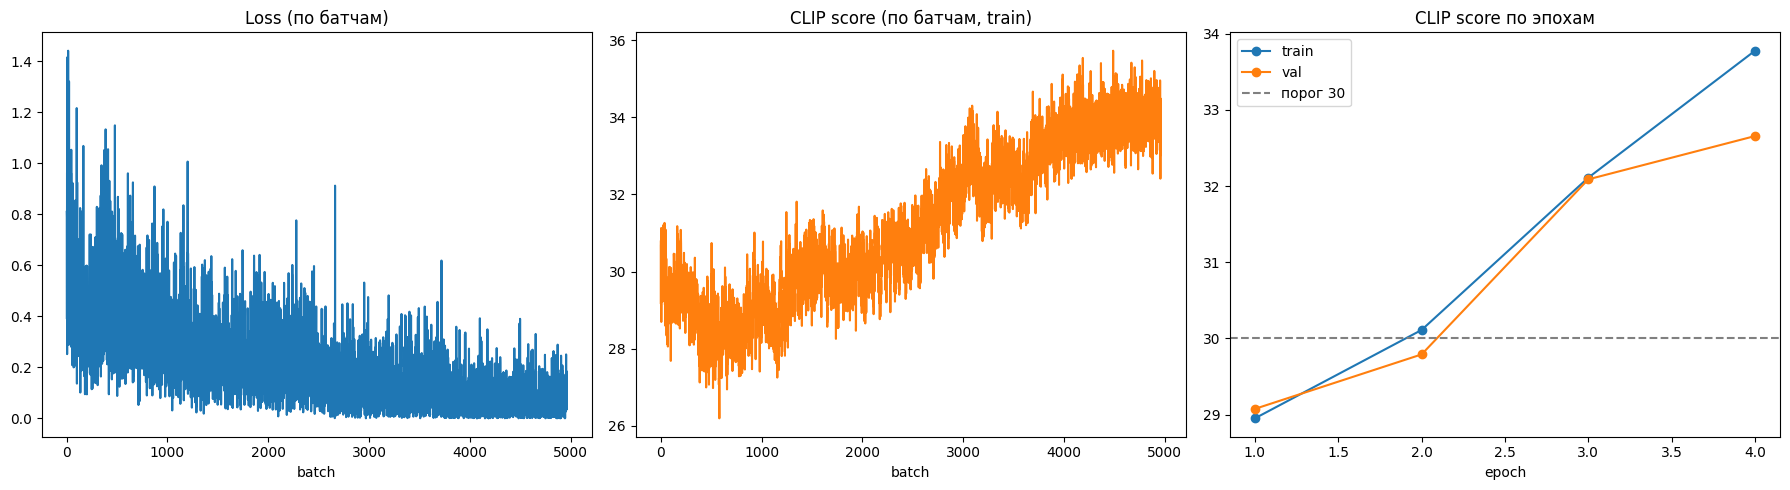

In [19]:
# Кривые обучения и валидации
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history["batch_loss"])
axes[0].set_title("Loss (по батчам)")
axes[0].set_xlabel("batch")

axes[1].plot(history["batch_score"], color="tab:orange")
axes[1].set_title("CLIP score (по батчам, train)")
axes[1].set_xlabel("batch")

ep = range(1, NUM_EPOCHS + 1)
axes[2].plot(ep, history["epoch_train_score"], "-o", label="train")
axes[2].plot(ep, history["epoch_val_score"], "-o", label="val")
axes[2].axhline(30, ls="--", c="gray", label="порог 30")
axes[2].set_title("CLIP score по эпохам")
axes[2].set_xlabel("epoch")
axes[2].legend()

plt.tight_layout()
plt.show()

Метрики и графики согласованы и говорят одно - обучение прошло корректно, сошлось за 3–4 эпохи, как и планировалось, порог 30 взят (val 32.66). Для улучшения я бы предложил не увеличивать количество эпох, а вникнуть в описания и поработать над текстами. Плюс у нас модель обрезала очень много и видила только начало описаний, так что так.

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(36, 233, 217) 0%, rgb(196, 16, 202) 30%, rgb(255, 255, 255) 60%, rgb(255, 255, 255) 100%); border-left: 4px solid #ffffff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: rgb(0, 0, 0); font-weight: 600;">БЛОК 2.1 Реализация системы поиска товаров. Работа с данными </strong>
</div>

Берём весь датасет, грузим лучший чекпоинт, один раз считаем и сохраняем эмбеддинги всех картинок.

In [20]:
BEST = os.path.join(CKPT_DIR, "clip_best")
model = CLIPModel.from_pretrained(BEST).to(DEVICE).eval()
processor = CLIPProcessor.from_pretrained(BEST)

full_df = df.reset_index(drop=True)
print("Товаров в базе:", len(full_df))

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Товаров в базе: 44158


Один раз считаем векторы для всех картинок и сохраняем их в файл.

In [21]:
def build_image_index(model, processor, df, image_dir, batch=64):

    """Считаем векторы всех картинок и дальше поиск сравнивает запрос с готовыми векторами

    Args:
        model (_type_): модель
        processor (_type_): процессор для нормализации картинок
        df (_type_): датафрейм
        image_dir (_type_): папка с картинками
        batch (int, optional): батчи. Defaults to 64.

    Returns:
        _type_: тензора нормированных векторов картинок для всей базы
    """    
    
    embs = []
    paths = df["image"].astype(str).tolist()
    model.eval()
    for i in tqdm(range(0, len(paths), batch), desc="Индексация картинок"):
        chunk = paths[i:i + batch]
        imgs = [Image.open(os.path.join(image_dir, p)).convert("RGB") for p in chunk]
        inp = processor(images=imgs, return_tensors="pt").to(DEVICE)
        f = encode_images(model, inp["pixel_values"])
        embs.append(f.cpu())
    return torch.cat(embs)

# Считаем один раз и кэшируем на диск
if os.path.exists(EMB_PATH):
    image_embeddings = torch.load(EMB_PATH)
    print("Загружены готовые эмбеддинги:", tuple(image_embeddings.shape))
else:
    image_embeddings = build_image_index(model, processor, full_df, IMAGE_DIR, batch=BATCH_SIZE)
    torch.save(image_embeddings, EMB_PATH)
    print("Посчитаны и сохранены:", tuple(image_embeddings.shape))

Индексация картинок:   0%|          | 0/1380 [00:00<?, ?it/s]

Посчитаны и сохранены: (44158, 512)


<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(36, 233, 217) 0%, rgb(196, 16, 202) 30%, rgb(255, 255, 255) 60%, rgb(255, 255, 255) 100%); border-left: 4px solid #ffffff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: rgb(0, 0, 0); font-weight: 600;">БЛОК 2.2-2.3 Функция поиска товаров и её текст</strong>
</div>

Собственно говоря тут мы напишим функцию поиска товаров и проведем тест запросов

In [22]:
def search_products(model, processor, image_embeddings, df, query,
                    top_k=5, image_dir=IMAGE_DIR):
    
    """Поиск товаров по текстовому запросу

    Args:
        model (_type_): Модель наша
        processor (_type_): Процессор для нормализации текста
        image_embeddings (_type_): векторы картино
        df (_type_): таблица товаров
        query (_type_): запросы
        top_k (int, optional): топ сколько то там значений. Defaults to 5.
        image_dir (_type_, optional): папка картинок. Defaults to IMAGE_DIR.

    Returns:
        _type_: картинка и текст
    """    
    
    model.eval()
    with torch.no_grad():
        inp = processor(text=[query], return_tensors="pt", padding=True,
                        truncation=True, max_length=MAX_TEXT_LEN).to(DEVICE)
        pooled = model.text_model(input_ids=inp["input_ids"],
                                  attention_mask=inp.get("attention_mask")).pooler_output
        t = model.text_projection(pooled)
        t = t / t.norm(p=2, dim=-1, keepdim=True)
        sims = (image_embeddings.to(DEVICE) @ t.T).squeeze(1)   # косинус
        top = sims.topk(min(top_k, sims.numel()))
    idxs = top.indices.cpu().numpy()
    scores = top.values.cpu().numpy()
    return [(df.iloc[i]["image"], df.iloc[i]["description"], float(sc))
            for i, sc in zip(idxs, scores)]

In [23]:
def show_search(query, top_k=5):
    """Поиск по запросу 

    Args:
        query (_type_): запрос
        top_k (int, optional): количество выводов. Defaults to 5.
    """    
    res = search_products(model, processor, image_embeddings, full_df, query, top_k=top_k)
    fig, axes = plt.subplots(1, top_k, figsize=(4 * top_k, 5))
    if top_k == 1:
        axes = [axes]
    for ax, (fname, desc, sc) in zip(axes, res):
        img = Image.open(os.path.join(IMAGE_DIR, str(fname))).convert("RGB")
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"score={sc:.3f}\n{textwrap.fill(str(desc), 28)[:120]}", fontsize=8)
    fig.suptitle(f'Запрос: "{query}"', fontsize=14)
    plt.tight_layout()
    plt.show()

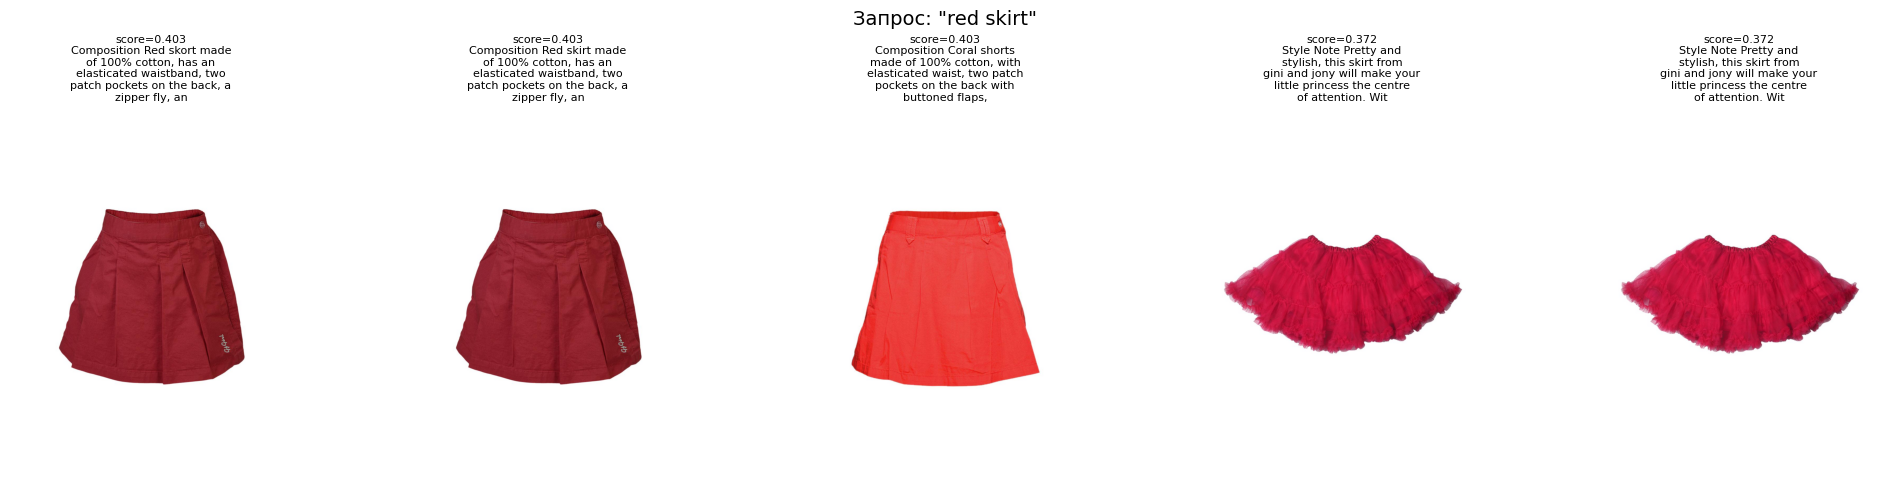

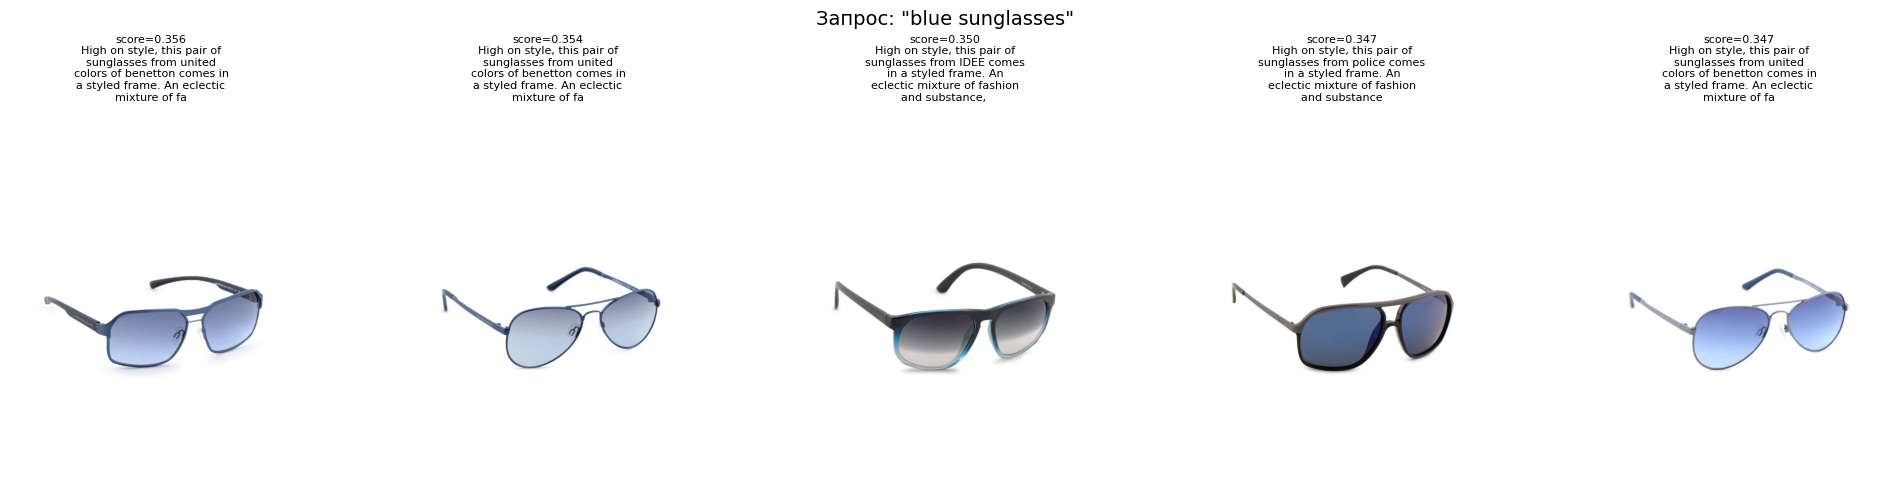

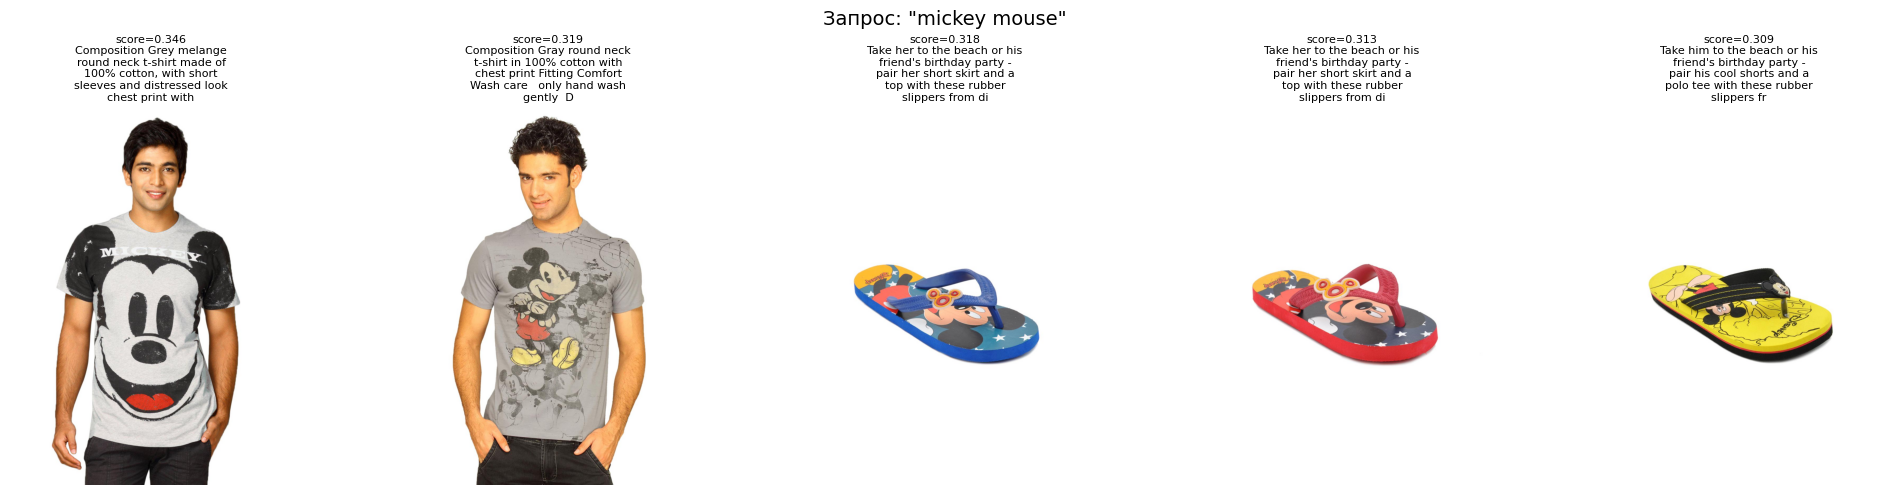

In [24]:
# непосредственно реализация
for q in ["red skirt", "blue sunglasses", "mickey mouse"]:
    show_search(q, top_k=5)

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(36, 233, 217) 0%, rgb(196, 16, 202) 30%, rgb(255, 255, 255) 60%, rgb(255, 255, 255) 100%); border-left: 4px solid #ffffff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: rgb(0, 0, 0); font-weight: 600;">Итоги работы</strong>
</div>

**Ну собственно говоря мы главное достигли целевой средний CLIP score > 30, хотя до обучения он уже был рядышком.**

И если проходить по этапам, то будет так:

- Загрузили таблицу (44 441 строка), оставили нужные колонки (`image`, `description`), убрали пустые описания и строки без файлов картинок. Разделили на обучение (90%) и тест (10%).
- Создали свой класс датасета`FashionDataset` отдаёт пары `картинка + описание`, а `DataLoader` собирает из них батчи.
- Реализовали цикл со стандартным контрастивным лоссом CLIP
- Про метрику уже сказали, что достигли
- Кривая лосса вышла на плато за 3-4 эпохи.
- Сохраняли модель после каждой эпохи и отдельно лучшую по тесту (`clip_best`), чтобы потом не обучать заново.

- Для всех 44 158 картинок заранее посчитали векторы и сохранили в файл `image_embeddings.pt`.
- На каждый запрос система кодирует только текст (одна короткая строка) и сравнивает его вектор со всеми готовыми векторами картинок по косинусной близости - картинки заново не пересчитываются.
- Поиск протестирован на запросах `red skirt`, `blue sunglasses`, `mickey mouse` - результаты отрисованы и вполне в рамках проекта вменяемы


Отдельные моментики:
- Описания у нас в каталоге длинные, более 100 слов.
- Предобученная модель уже была сильной, почти доходила до метрики требуемой
- Можно попробовать предобработать и улучшить текст с помощью нейросетей
- Можно попроовать обучить чуть дольше или взять CLIP c более длинным текстовым входом, хотя у нас задача по коротким запросам идет, может и не надо для этой задачи - это так мысли вслух.